# 7. Visual P300: De eventos reais a predições em sujeitos fora do dataset

Vamos carregar três gravações de visual-oddball: dos sujeitos 054, 119 e 123.

Uma tarefa oddball apresenta estímulos frequentes e padronizados. Ocasionalmente, o estímulo é substituído por um target "oddball" raro que difere em cor/forma/orientação.

## 7.1 Selecionando gravações

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd
from braindecode.preprocessing import RemoveCommonAverageReference, RemoveDCOffset
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, balanced_accuracy_score
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from eegdash import EEGDashDataset
from eegdash.features import signal_mean

cache_dir = Path(os.environ.get("EEGDASH_CACHE_DIR", ".eegdash_cache"))
subjects = ["054", "119", "123"]
dataset = EEGDashDataset(
    cache_dir=cache_dir,
    dataset="ds005863",
    subject=subjects,
    task="visualoddball",
    n_jobs=1,
)
assert len(dataset.datasets) == len(subjects)
print(dataset.description[["subject", "task"]])

/home/arielalves/Desktop/Iniciacao-cientifica-EEG-FM/EEGDash-Tutorials/Translated-Tutorials/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/arielalves/Desktop/Iniciacao-cientifica-EEG-FM/EEGDash-Tutorials/Translated-Tutorials/.venv/lib/python3.12/site-packages/braindecode/models/eegpt.py:497: FutureWarning: Montage name 'standard_1020' is deprecated and will be removed in MNE 1.14. Use 'colin27_1020' instead.
  montage = mne.channels.make_standard_montage("standard_1020")
/home/arielalves/Desktop/Iniciacao-cientifica-EEG-FM/EEGDash-Tutorials/Translated-Tutorials/.venv/lib/python3.12/site-packages/braindecode/models/eegpt.py:1452: FutureWarning: Montage name 'standard_1020' is deprecated and will be removed in MNE 1.14. Use 'colin27_1020' instead.
  montage = make_standard_montage("standard_1

[09/13/26 16:46:20] INFO     Auto-corrected misrouted storage.base for dataset on005863:             ]8;id=11728860;file:///home/arielalves/Desktop/Iniciacao-cientifica-EEG-FM/EEGDash-Tutorials/Translated-Tutorials/.venv/lib/python3.12/site-packages/eegdash/dataset/dataset.py\dataset.py]8;;\:]8;id=11728861;file:///home/arielalves/Desktop/Iniciacao-cientifica-EEG-FM/EEGDash-Tutorials/Translated-Tutorials/.venv/lib/python3.12/site-packages/eegdash/dataset/dataset.py#561\561]8;;\
                             s3://nemar/on005863 -> s3://openneuro.org/ds005863                                    

  subject           task
0     054  visualoddball
1     119  visualoddball
2     123  visualoddball


## 7.2 Mapear eventos gravados e preparar features de tentativas

No código XY, X é a letra-alvo do bloco e Y é a letra apresentada, ambas codificadas de 1 a 5. Dígitos correspondentes indicam alvos (targets). Exclua explicitamente respostas e outros marcadores em vez de classificar todas as demais anotações como padrões (standards). Alguns leitores adicionam o prefixo `Stimulus/` aos nomes. Por exemplo, `S11` é mapeado como alvo (2), enquanto `S12` é mapeado como padrão (1). Subtrair um após a criação das épocas (epoching) resulta nos rótulos de classificação 0 e 1.

As épocas do MNE alinham cada ensaio ao instante zero no estímulo registrado. A linha de base de -100 a 0 ms subtrai a média pré-estímulo de cada canal daquele ensaio. O filtro de 0,5 a 30 Hz atenua desvios lentos (slow drift) e atividades mais rápidas; alterá-lo pode modificar a amplitude dos ERPs e deve ser definido antes de comparar pontuações. O EEGPrep remove o deslocamento mediano (median offset) de cada canal; em seguida, sua referência média comum (common-average reference) subtrai a média instantânea dos canais de EEG. Essas operações não descartam amostras. Verificamos a grade temporal e restauramos as anotações originais explicitamente porque as conversões entre MNE e EEGLAB podem arredondar as latências dos eventos.

Reamostrar as épocas para 128 Hz reduz o uso de memória após os eventos terem sido localizados na grade amostral original. `X` tem eixos (ensaios, canais, tempo) expressos em volts. A função `signal_mean` do EEGDash no intervalo de 300 a 450 ms gera uma amplitude por canal e por ensaio; multiplicar por 1e6 a converte para microvolts. Esse intervalo fixo serve como uma linha de base compacta, não como uma afirmação de que o pico de cada participante ocorra exatamente nessa janela. As amplitudes de todos os canais alimentam o decodificador; o eletrodo Pz é utilizado apenas para a visualização do ERP ilustrativo.

O parâmetro `reject_by_annotation` respeita intervalos já marcados como ruins. Ele não detecta todos os piscares de olhos ou canais ruidosos: inspecione as gravações e defina regras adicionais de controle de qualidade antes de expandir esta análise.

In [3]:
features, labels, groups = [], [], []
first_epochs = None
channel_names = None
for recording in dataset.datasets:
    raw = recording.raw.copy().load_data().pick("eeg")
    mapping = {}
    for name in set(raw.annotations.description):
        code = name.split("/")[-1].replace(" ", "")
        if len(code) == 3 and code[0] == "S" and set(code[1:]) <= set("12345"):
            mapping[name] = 2 if code[1] == code[2] else 1
    assert set(mapping.values()) == {1, 2}, "Missing target or standard markers"
    print(recording.description["subject"], mapping)

    # Preprocess, epoch and baseline-correct
    # Filtering is independent for each recording. Epochs span -0.1..0.8 s
    # relative to stimulus onset, irrespective of annotation duration.
    source_annotations = raw.annotations.copy()
    source_date = raw.info["meas_date"]
    source_grid = (raw.info["sfreq"], raw.n_times, raw.first_samp)
    RemoveDCOffset().apply(raw)
    RemoveCommonAverageReference().apply(raw)
    assert (raw.info["sfreq"], raw.n_times, raw.first_samp) == source_grid
    raw.set_meas_date(source_date)
    raw.set_annotations(source_annotations)
    raw.filter(0.5, 30.0)
    events, _ = mne.events_from_annotations(raw, event_id=mapping)
    epochs = mne.Epochs(
        raw,
        events,
        event_id={"standard": 1, "target": 2},
        tmin=-0.1,
        tmax=0.8,
        baseline=(-0.1, 0),
        preload=True,
        reject_by_annotation=True,
    )
    epochs.resample(128)
    if channel_names is None:
        channel_names = epochs.ch_names
        first_epochs = epochs
    assert epochs.ch_names == channel_names
    assert "Pz" in epochs.ch_names, "This ERP example requires Pz"
    X = epochs.get_data()
    y = epochs.events[:, 2] - 1
    assert set(y) == {0, 1} and np.isfinite(X).all()

    # Use a fixed analysis interval; do not choose it from test accuracy.
    interval = (epochs.times >= 0.3) & (epochs.times <= 0.45)
    features.append(signal_mean(X[:, :, interval]) * 1e6)
    labels.append(y)
    groups.extend([str(recording.description["subject"])] * len(y))

Reading 0 ... 187519  =      0.000 ...   375.038 secs...
054 {'S 52': 1, 'S 23': 1, 'S 24': 1, 'S 14': 1, 'S 42': 1, 'S 33': 2, 'S 54': 1, 'S 44': 2, 'S 25': 1, 'S 43': 1, 'S 21': 1, 'S 13': 1, 'S 12': 1, 'S 11': 2, 'S 15': 1, 'S 32': 1, 'S 45': 1, 'S 31': 1, 'S 41': 1, 'S 34': 1, 'S 53': 1, 'S 55': 2, 'S 51': 1, 'S 22': 2, 'S 35': 1}


[09/13/26 16:52:43] INFO     eeg_checkset: xmax adjusted to match pnts, xmin, and srate         ]8;id=11729000;file:///home/arielalves/Desktop/Iniciacao-cientifica-EEG-FM/EEGDash-Tutorials/Translated-Tutorials/.venv/lib/python3.12/site-packages/eegprep/functions/adminfunc/eeg_checkset.py\eeg_checkset.py]8;;\:]8;id=11729001;file:///home/arielalves/Desktop/Iniciacao-cientifica-EEG-FM/EEGDash-Tutorials/Translated-Tutorials/.venv/lib/python3.12/site-packages/eegprep/functions/adminfunc/eeg_checkset.py#436\436]8;;\

                    WARNING  EEGPrep event count changed during RemoveDCOffset processing ]8;id=11729006;file:///home/arielalves/Desktop/Iniciacao-cientifica-EEG-FM/EEGDash-Tutorials/Translated-Tutorials/.venv/lib/python3.12/site-packages/braindecode/preprocessing/eegprep_preprocess.py\eegprep_preprocess.py]8;;\:]8;id=11729007;file:///home/arielalves/Desktop/Iniciacao-cientifica-EEG-FM/EEGDash-Tutorials/Translated-Tutorials/.venv/lib/python3.12/site-packages/braindecode/preprocessing/eegprep_preprocess.py#123\123]8;;\
                             (412 annotated events, 411 non-boundary events); restoring                            
                             durations in order for the overlapping subset only.                                   

                    WARNING  EEGPrep event count changed during RemoveDCOffset processing ]8;id=11729012;file:///home/arielalves/Desktop/Iniciacao-cientifica-EEG-FM/EEGDash-Tutorials/Translated-Tutorials/.venv/lib/python3.12/site-packages/braindecode/preprocessing/eegprep_preprocess.py\eegprep_preprocess.py]8;;\:]8;id=11729013;file:///home/arielalves/Desktop/Iniciacao-cientifica-EEG-FM/EEGDash-Tutorials/Translated-Tutorials/.venv/lib/python3.12/site-packages/braindecode/preprocessing/eegprep_preprocess.py#123\123]8;;\
                             (412 annotated events, 411 non-boundary events); restoring                            
                             durations in order for the overlapping subset only.                                   

                    INFO     eeg_checkset: xmax adjusted to match pnts, xmin, and srate         ]8;id=11729018;file:///home/arielalves/Desktop/Iniciacao-cientifica-EEG-FM/EEGDash-Tutorials/Translated-Tutorials/.venv/lib/python3.12/site-packages/eegprep/functions/adminfunc/eeg_checkset.py\eeg_checkset.py]8;;\:]8;id=11729019;file:///home/arielalves/Desktop/Iniciacao-cientifica-EEG-FM/EEGDash-Tutorials/Translated-Tutorials/.venv/lib/python3.12/site-packages/eegprep/functions/adminfunc/eeg_checkset.py#436\436]8;;\

...

[09/13/26 16:52:45] INFO     eeg_checkset: xmax adjusted to match pnts, xmin, and srate         ]8;id=11729048;file:///home/arielalves/Desktop/Iniciacao-cientifica-EEG-FM/EEGDash-Tutorials/Translated-Tutorials/.venv/lib/python3.12/site-packages/eegprep/functions/adminfunc/eeg_checkset.py\eeg_checkset.py]8;;\:]8;id=11729049;file:///home/arielalves/Desktop/Iniciacao-cientifica-EEG-FM/EEGDash-Tutorials/Translated-Tutorials/.venv/lib/python3.12/site-packages/eegprep/functions/adminfunc/eeg_checkset.py#436\436]8;;\

                    WARNING  EEGPrep event count changed during RemoveDCOffset processing ]8;id=11729054;file:///home/arielalves/Desktop/Iniciacao-cientifica-EEG-FM/EEGDash-Tutorials/Translated-Tutorials/.venv/lib/python3.12/site-packages/braindecode/preprocessing/eegprep_preprocess.py\eegprep_preprocess.py]8;;\:]8;id=11729055;file:///home/arielalves/Desktop/Iniciacao-cientifica-EEG-FM/EEGDash-Tutorials/Translated-Tutorials/.venv/lib/python3.12/site-packages/braindecode/preprocessing/eegprep_preprocess.py#123\123]8;;\
                             (412 annotated events, 411 non-boundary events); restoring                            
                             durations in order for the overlapping subset only.                                   

[09/13/26 16:52:46] WARNING  EEGPrep event count changed during RemoveDCOffset processing ]8;id=11729060;file:///home/arielalves/Desktop/Iniciacao-cientifica-EEG-FM/EEGDash-Tutorials/Translated-Tutorials/.venv/lib/python3.12/site-packages/braindecode/preprocessing/eegprep_preprocess.py\eegprep_preprocess.py]8;;\:]8;id=11729061;file:///home/arielalves/Desktop/Iniciacao-cientifica-EEG-FM/EEGDash-Tutorials/Translated-Tutorials/.venv/lib/python3.12/site-packages/braindecode/preprocessing/eegprep_preprocess.py#123\123]8;;\
                             (412 annotated events, 411 non-boundary events); restoring                            
                             durations in order for the overlapping subset only.                                   

                    INFO     eeg_checkset: xmax adjusted to match pnts, xmin, and srate         ]8;id=11729066;file:///home/arielalves/Desktop/Iniciacao-cientifica-EEG-FM/EEGDash-Tutorials/Translated-Tutorials/.venv/lib/python3.12/site-packages/eegprep/functions/adminfunc/eeg_checkset.py\eeg_checkset.py]8;;\:]8;id=11729067;file:///home/arielalves/Desktop/Iniciacao-cientifica-EEG-FM/EEGDash-Tutorials/Translated-Tutorials/.venv/lib/python3.12/site-packages/eegprep/functions/adminfunc/eeg_checkset.py#436\436]8;;\

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 3301 samples (6.602 s)

Used Annotations descriptions: ['S 11', 'S 12', 'S 13', 'S 14', 'S 15', 'S 21', 'S 22', 'S 23', 'S 24', 'S 25', 'S 31', 'S 32', 'S 33', 'S 34', 'S 35', 'S 41', 'S 42', 'S 43', 'S 44', 'S 45', 'S 51', 'S 52', 'S 53', 'S 54', 'S 55']
Not setting metadata
200 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 200 events and 451 original time points ...
0 bad epo

## 7.3 Avaliar um sujeito nunca visto por fold

O `StandardScaler` é ajustado dentro de cada dobra de treino. A acurácia balanceada atribui o mesmo peso a alvos (targets) e padrões (standards), apesar do desbalanceamento inerente ao paradigma oddball. A concatenação empilha os ensaios, enquanto `groups` preserva a identidade de cada participante. Analise a tabela de contagem de classes antes do treinamento: prever sempre a classe padrão pode gerar uma acurácia comum alta, mas a acurácia balanceada binária seria de 0,5.

A regressão logística aprende uma combinação linear das amplitudes dos canais. Os pesos de classe no treino conferem aos alvos — que são mais raros — maior influência sobre sua função de perda (loss). Isso afeta o ajuste (fitting); a acurácia balanceada calcula separadamente a média das revocatórias (recalls) das duas classes durante a avaliação. Cada dobra LOSO (Leave-One-Subject-Out) treina com dois participantes completos e testa no terceiro. Uma divisão aleatória de ensaios responderia a uma pergunta diferente, pois permitiria a presença do mesmo participante nos conjuntos de treino e de teste simultaneamente.

In [ ]:
X = np.concatenate(features)
y = np.concatenate(labels)
groups = np.asarray(groups)
print(pd.crosstab(groups, y, rownames=["subject"], colnames=["class"]))
predictions = np.full(len(y), -1)
counts = np.zeros(len(y), dtype=int)
rows = []

# Modelo para tentar prever as classes (0 ou 1)
for train, test in LeaveOneGroupOut().split(X, y, groups):
    assert set(groups[train]).isdisjoint(groups[test])
    model = make_pipeline(
        StandardScaler(), LogisticRegression(class_weight="balanced", max_iter=1000)
    )
    model.fit(X[train], y[train])
    predictions[test] = model.predict(X[test])
    counts[test] += 1
    rows.append(
        {
            "subject": groups[test][0],
            "balanced_accuracy": balanced_accuracy_score(y[test], predictions[test]),
        }
    )
assert np.all(counts == 1)
print(pd.DataFrame(rows).to_string(index=False))

class      0   1
subject         
054      160  40
119      160  40
123      160  40
subject  balanced_accuracy
    054           0.621875
    119           0.612500
    123           0.481250


## 7.4 Inspecionar o ERP medido e erros de decodificação

O gráfico compara a média dos potenciais evocados (ERP) da primeira gravação no eletrodo Pz para as condições standard e target.

A matriz de confusão utiliza predições fora do dataset. Um P300 visível ou score alto não é um requisito de teste. Isso demonstra um fluxo de processo, não um benchmark. Na matriz de confusão normalizada, o primeiro bloco são os verdadeiros negativos (classe standard corretamente identificada), seguido pelos falsos positivos (classe standard identificada como target). Na linha abaixo, temos os falsos negativos seguidos pelos verdadeiros positivos.

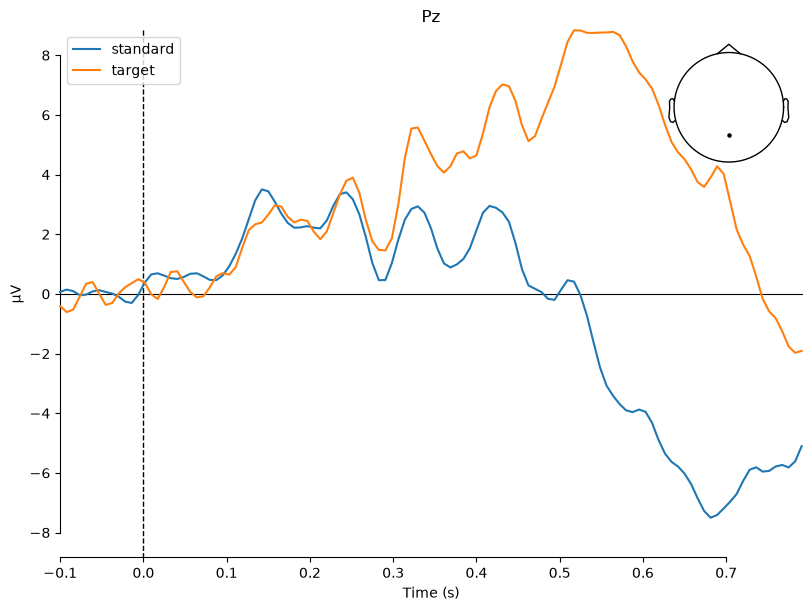

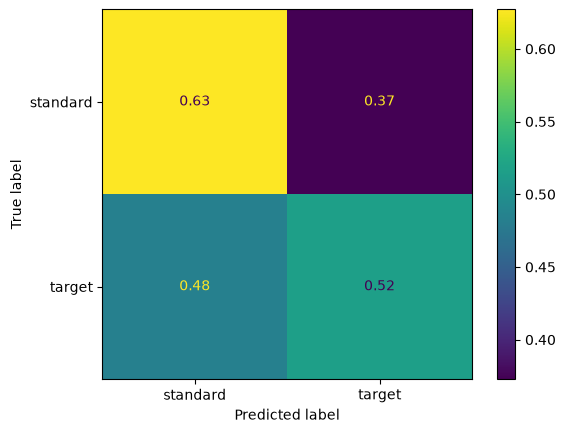

In [5]:
mne.viz.plot_compare_evokeds(
    {name: first_epochs[name].average() for name in ["standard", "target"]},
    picks="Pz",
    show=False,
)
ConfusionMatrixDisplay.from_predictions(
    y, predictions, display_labels=["standard", "target"], normalize="true"
)
plt.show()